In [55]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

In [56]:
%matplotlib inline

In [57]:
df = pd.read_csv("titanic_train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



# Data Cleaning

``Visualizing the missing values using heatmap and missigno``

<Axes: >

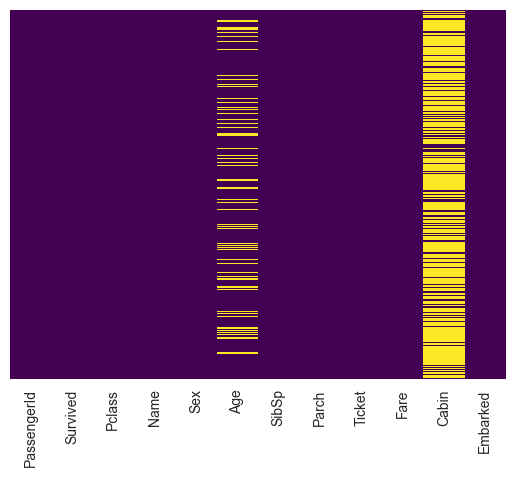

In [58]:
sns.heatmap(df.isnull(), yticklabels =False , cbar= False, cmap = "viridis")

<Axes: >

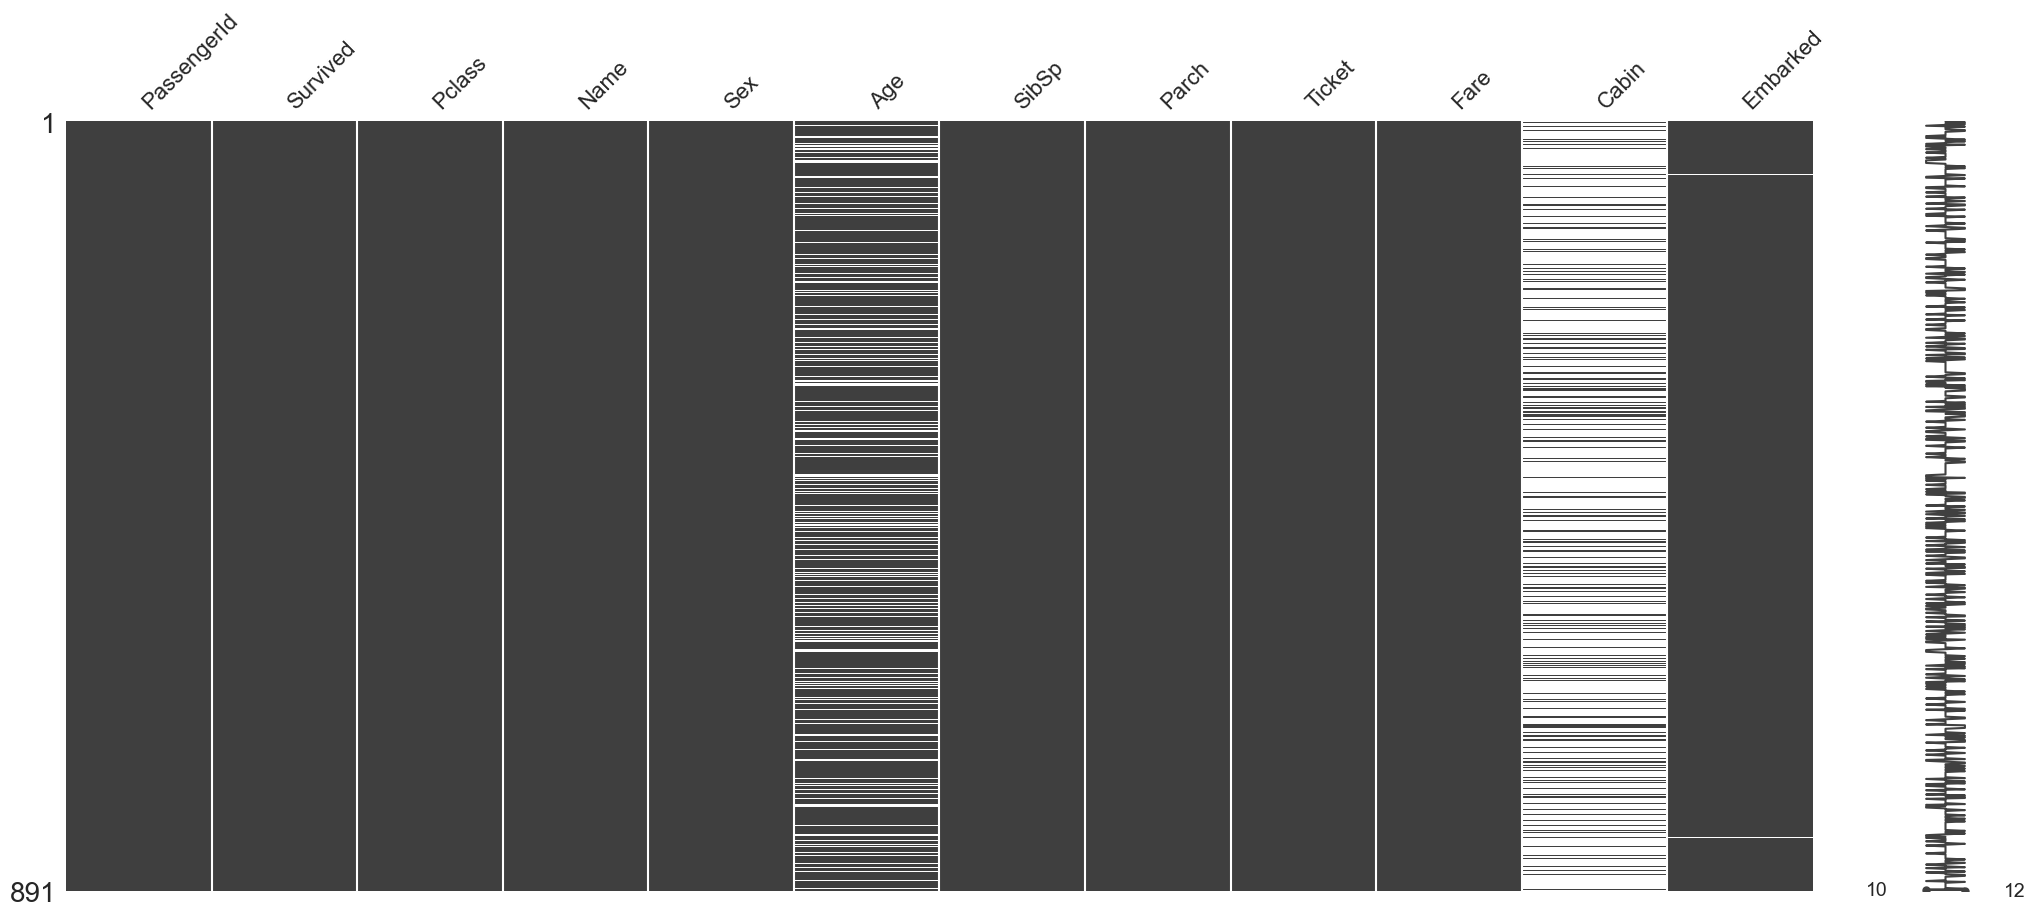

In [59]:
msno.matrix(df)

In [60]:
#Imputing the missing values using the median in the age column
def impute_age(cols):
    Age = cols[0]
    Pclass= cols[1]
    if pd.isnull(Age):
        if Pclass == 1:
            return 38
        elif Pclass == 2:
            return 29
        else:
            return 24   
    else:
        return Age
df['Age']= df[['Age','Pclass']].apply(impute_age, axis = 1)

C:\Users\HP\AppData\Local\Temp\ipykernel_21688\3327995772.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age = cols[0]
C:\Users\HP\AppData\Local\Temp\ipykernel_21688\3327995772.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass= cols[1]


In [61]:
df.nunique()



PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [62]:
#Drop high dimensional columns
df.drop(columns= ["Name", "PassengerId", "Ticket", "Fare"], inplace= True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Cabin,Embarked
0,0,3,male,22.0,1,0,NaN,S
1,1,1,female,38.0,1,0,C85,C
2,1,3,female,26.0,0,0,NaN,S
3,1,1,female,35.0,1,0,C123,S
4,0,3,male,35.0,0,0,NaN,S


# Exploratory Analysis

In [63]:
sns.set_style("darkgrid")

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and w

<Axes: xlabel='Survived', ylabel='count'>

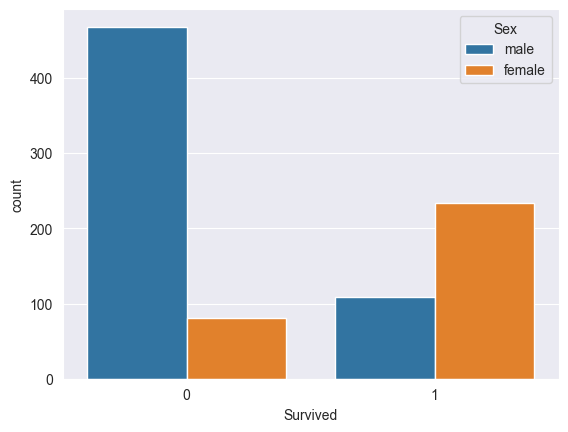

In [64]:
sns.countplot(x="Survived",hue = "Sex", data = df)


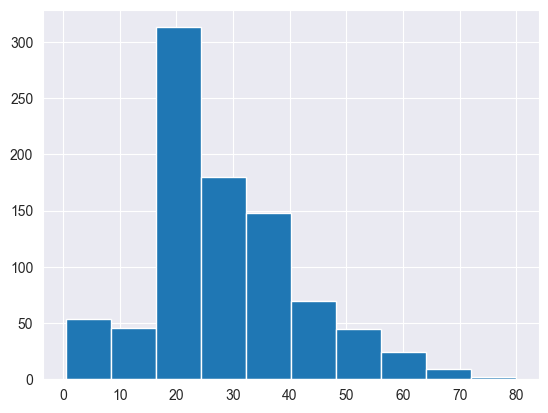

In [65]:
plt.hist(df['Age'])
plt.show()

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


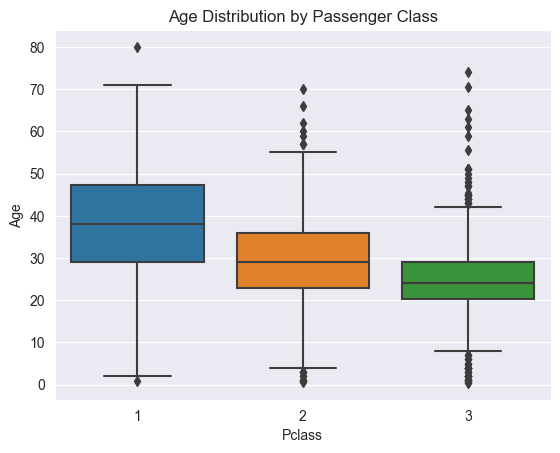

In [66]:

sns.boxplot(x="Pclass", y = "Age", data = df)
plt.title('Age Distribution by Passenger Class');

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and w

([<matplotlib.axis.XTick at 0x1fbd99eca90>,
 [Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')])

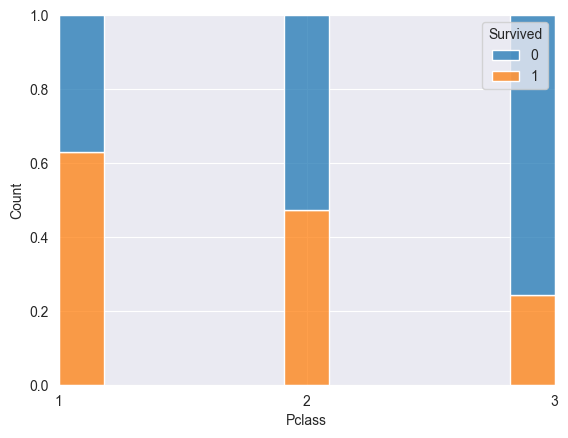

In [67]:
sns.histplot(hue="Survived",x = "Pclass",multiple="fill", data = df)
plt.xticks([1,2,3])

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and w

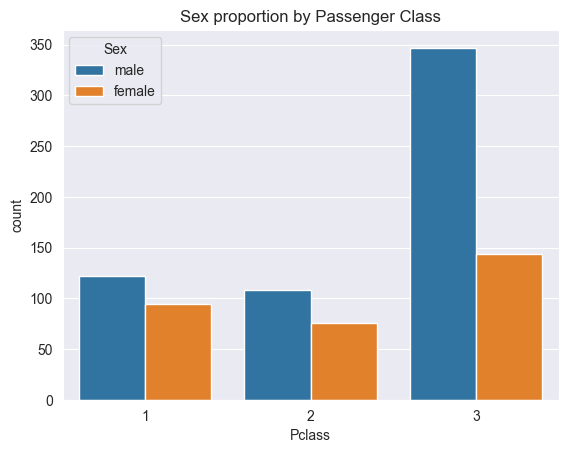

In [68]:
sns.countplot(x="Pclass",hue = "Sex", data = df)
plt.title("Sex proportion by Passenger Class")
plt.show()

In [69]:
X = df.drop(columns = ["Survived"], axis = 1)
y = df["Survived"]
X.head()

,Pclass,Sex,Age,SibSp,Parch,Cabin,Embarked
0,3,male,22.0,1,0,NaN,S
1,1,female,38.0,1,0,C85,C
2,3,female,26.0,0,0,NaN,S
3,1,female,35.0,1,0,C123,S
4,3,male,35.0,0,0,NaN,S


<Axes: >

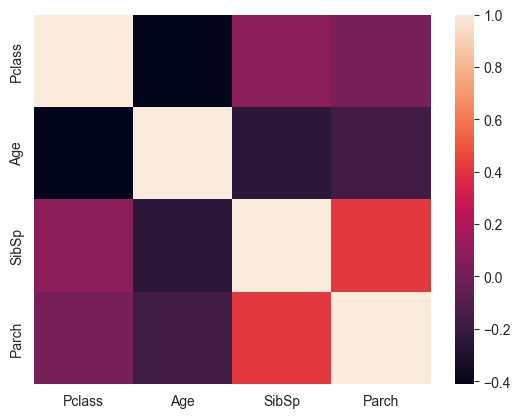

In [70]:
# To check for Colinearity
sns.heatmap(X.select_dtypes("number").corr())

**To check the impact of the numerical columns on the target variable** 

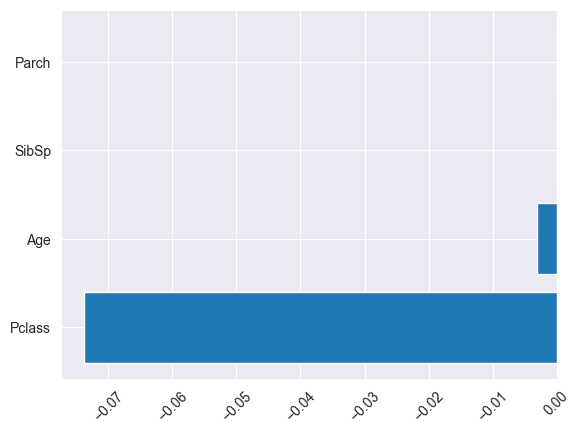

In [71]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha = 0.1)
lasso_coef = lasso.fit(X.select_dtypes("number"),y).coef_
plt.barh(X.select_dtypes("number").columns, lasso_coef)
plt.xticks(rotation = 45)
plt.show()

**Drop the non-impactful columns**

In [72]:
X.drop(columns = ["SibSp","Parch"], inplace = True)


**Fill missing entries using** ``SimpleImputer``

In [73]:

# Select numerical and string columns individually
num_cols = df.select_dtypes(include=[np.number]).columns
str_cols = df.select_dtypes(include=[object]).columns

# Impute numerical columns
num_imputer = SimpleImputer(strategy="mean")
imputed_num_data = num_imputer.fit_transform(df[num_cols])

# Impute string columns
str_imputer = SimpleImputer(strategy="most_frequent")
imputed_str_data = str_imputer.fit_transform(df[str_cols])

# Combine imputed data into a new DataFrame (assuming columns have matching names)
df_imputed = pd.concat([pd.DataFrame(imputed_num_data, columns=num_cols),
                       pd.DataFrame(imputed_str_data, columns=str_cols)], axis=1)

# Print the first 5 rows of the imputed DataFrame
df_imputed.head()



,Survived,Pclass,Age,SibSp,Parch,Sex,Cabin,Embarked
0,0.0,3.0,22.0,1.0,0.0,male,B96 B98,S
1,1.0,1.0,38.0,1.0,0.0,female,C85,C
2,1.0,3.0,26.0,0.0,0.0,female,B96 B98,S
3,1.0,1.0,35.0,1.0,0.0,female,C123,S
4,0.0,3.0,35.0,0.0,0.0,male,B96 B98,S


``ENCODE THE STRING COLUMNS``

In [74]:

# Select columns for encoding
columns_to_encode = ['Sex', 'Embarked']

# Create and fit OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)
encoder.fit(df_imputed[columns_to_encode])

# Transform selected columns
encoded_df = pd.DataFrame(encoder.transform(df_imputed[columns_to_encode]), columns=encoder.get_feature_names_out())

# Combine encoded columns with original DataFrame
df = pd.concat([df_imputed.drop(columns_to_encode, axis=1), encoded_df], axis=1)

df.head()


c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


,Survived,Pclass,Age,SibSp,Parch,Cabin,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0.0,3.0,22.0,1.0,0.0,B96 B98,0.0,1.0,0.0,0.0,1.0
1,1.0,1.0,38.0,1.0,0.0,C85,1.0,0.0,1.0,0.0,0.0
2,1.0,3.0,26.0,0.0,0.0,B96 B98,1.0,0.0,0.0,0.0,1.0
3,1.0,1.0,35.0,1.0,0.0,C123,1.0,0.0,0.0,0.0,1.0
4,0.0,3.0,35.0,0.0,0.0,B96 B98,0.0,1.0,0.0,0.0,1.0


# CREATING A WRANGLE FUNCTION

In [75]:
def wrangle(path):
    df = pd.read_csv(path)
    #Drop high dimensional columns
    df.drop(columns= ["Name", "Ticket", "Fare"], inplace= True)
    #Remove missing values

    # Select numerical and string columns individually
    num_cols = df.select_dtypes(include=[np.number]).columns
    str_cols = df.select_dtypes(include=[object]).columns
    # Impute numerical columns
    num_imputer = SimpleImputer(strategy="mean")
    imputed_num_data = num_imputer.fit_transform(df[num_cols])
    # Impute string columns
    str_imputer = SimpleImputer(strategy="most_frequent")
    imputed_str_data = str_imputer.fit_transform(df[str_cols])
    # Combine imputed data into a new DataFrame (assuming columns have matching names)
    df_imputed = pd.concat([pd.DataFrame(imputed_num_data, columns=num_cols),
                        pd.DataFrame(imputed_str_data, columns=str_cols)], axis=1)
    # Print the first 5 rows of the imputed DataFrame
    df_imputed.head()
    
    #Encode the object columns
    # Select columns for encoding
    columns_to_encode = ['Sex', 'Embarked']
    # Create and fit OneHotEncoder
    encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)
    encoder.fit(df_imputed[columns_to_encode])
    # Transform selected columns
    encoded_df = pd.DataFrame(encoder.transform(df_imputed[columns_to_encode]), columns=encoder.get_feature_names_out())
    # Combine encoded columns with original DataFrame
    df = pd.concat([df_imputed.drop(columns_to_encode, axis=1), encoded_df], axis=1)

    #Drop non-impactful column
    df.drop(columns = ["SibSp","Parch"], inplace = True)
    #cabin column
    df.drop(columns = "Cabin", inplace = True)

    return df

In [76]:
df = wrangle("titanic_train.csv")
df.head()

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


,PassengerId,Survived,Pclass,Age,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1.0,0.0,3.0,22.0,0.0,1.0,0.0,0.0,1.0
1,2.0,1.0,1.0,38.0,1.0,0.0,1.0,0.0,0.0
2,3.0,1.0,3.0,26.0,1.0,0.0,0.0,0.0,1.0
3,4.0,1.0,1.0,35.0,1.0,0.0,0.0,0.0,1.0
4,5.0,0.0,3.0,35.0,0.0,1.0,0.0,0.0,1.0


In [77]:
# we can see that the important feature that determines the reponse variable is Sex(Male), Fare and Age

In [78]:
y_train  = df["Survived"]
X_train = df.drop(columns = ["Survived", "PassengerId"], axis = 1)

In [79]:
X_test = wrangle("titanic_test.csv")
test = X_test.drop(columns = ["PassengerId"], axis = 1)
test.head()

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


,Pclass,Age,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,3.0,34.5,0.0,1.0,0.0,1.0,0.0
1,3.0,47.0,1.0,0.0,0.0,0.0,1.0
2,2.0,62.0,0.0,1.0,0.0,1.0,0.0
3,3.0,27.0,0.0,1.0,0.0,0.0,1.0
4,3.0,22.0,1.0,0.0,0.0,0.0,1.0


In [80]:
X_test.isnull().sum()

PassengerId    0
Pclass         0
Age            0
Sex_female     0
Sex_male       0
Embarked_C     0
Embarked_Q     0
Embarked_S     0
dtype: int64

In [81]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier

In [82]:
dtree = DecisionTreeClassifier(min_samples_leaf = 0.1, random_state = 21)
logreg = LogisticRegression()
KNN = KNeighborsClassifier(n_neighbors =5)

In [83]:
classifiers = [('Logistic Regression', logreg),
               ('Classification Tree', dtree),
               ('K Nearest Neighbors', KNN)]

vc = VotingClassifier(estimators = classifiers)
vc.fit(X_train, y_train)
y_pred = vc.predict(test)

In [84]:
y_pred

array([0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 1., 1., 0.,
       0., 1., 0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 0., 0.,
       0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 1., 0., 0.,
       0., 1., 1., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0.,
       0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 0., 0., 1., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1., 0., 0., 0., 1.,
       1., 1., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
       0., 0., 0., 1., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 1.,
       0., 0., 0., 0., 0., 1., 1., 0., 1., 1., 0., 0., 1., 0., 1., 0., 1.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 1.,
       0., 0., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 1.,
       0., 1., 0., 1., 1.

In [85]:
output = pd.DataFrame({'PassengerID':X_test.PassengerId, 'Survived': y_pred})
output.to_csv("C:\\Users\\HP\\Desktop\\titanic_submission.csv", index = False)

In [86]:
submission =pd.read_csv("submission.csv")

submission.head()

,PassengerID,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
